# Bridge Diagnostic
Step-by-step inspection: T_eng predictor → bridge ODE → Whisper decode.

In [2]:
import os, sys, json, torch
import numpy as np

os.environ.setdefault('TRAIN_DATA_DIR', '/vol/gpudata/tsv22-train/data/processed/train')
os.environ.setdefault('DEV_DATA_DIR',   '/vol/gpudata/tsv22-dev_test/data/processed/dev')
os.environ.setdefault('TEST_DATA_DIR',  '/vol/gpudata/tsv22-dev_test/data/processed/test')

ROOT = '/vol/gpudata/tsv22-fyp/accent-robust-asr'
sys.path.insert(0, ROOT)
os.chdir(ROOT)

BRIDGE_CKPT    = 'models/bridge_dtw_x0_cond/checkpoint_best.pt'
PREDICTOR_CKPT = 'models/teng_predictor/model_best.pt'

# Dev pair — has both z_acc and z_nat so we can compare predictor vs GT T_eng
# and measure actual cosine sim to ground-truth native latent
PAIR = {
    "l2_speaker":            "RRBI",
    "l2_utterance_id":       "arctic_b0175",
    "l2_encoder_state_path": "RRBI/RRBI_arctic_b0175.pt",
    "nat_speaker":           "CLB",
    "nat_encoder_state_path":"CLB/CLB_arctic_b0175.pt",
    "l2_speech_end_frame":   145,
    "nat_speech_end_frame":  152,
    "text":                  "Sheldon glanced at the thermometer",
    "l1":                    "Hindi",
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(f'Utterance: "{PAIR["text"]}"  |  l2={PAIR["l2_speaker"]}  nat={PAIR["nat_speaker"]}')

device: cuda
Utterance: "Sheldon glanced at the thermometer"  |  l2=RRBI  nat=CLB


## 1. Load encoder state

In [3]:
from pathlib import Path

dev_dir   = Path(os.environ['DEV_DATA_DIR'])
train_dir = Path(os.environ['TRAIN_DATA_DIR'])

def load_state(rel_path):
    for d in [dev_dir, train_dir]:
        p = d / rel_path
        if p.exists():
            s = torch.load(p, map_location='cpu', weights_only=False)
            return s['hidden_states'].float(), p
    return None, None

z_acc, p_acc = load_state(PAIR['l2_encoder_state_path'])
z_nat, p_nat = load_state(PAIR['nat_encoder_state_path'])

assert z_acc is not None, f"z_acc not found: {PAIR['l2_encoder_state_path']}"
assert z_nat is not None, f"z_nat not found: {PAIR['nat_encoder_state_path']}"

T_l2     = PAIR['l2_speech_end_frame']
T_eng_gt = PAIR['nat_speech_end_frame']

print(f'z_acc loaded from: {p_acc}')
print(f'z_nat loaded from: {p_nat}')
print(f'T_l2={T_l2}  T_eng_gt={T_eng_gt}')
print(f'z_acc speech scale: {z_acc[:T_l2].norm(dim=-1).mean():.3f}')
print(f'z_nat speech scale: {z_nat[:T_eng_gt].norm(dim=-1).mean():.3f}')
cos_baseline = torch.nn.functional.cosine_similarity(
    z_acc[:min(T_l2, T_eng_gt)], z_nat[:min(T_l2, T_eng_gt)], dim=-1).mean()
print(f'Baseline cos_sim(z_acc, z_nat): {cos_baseline:.4f}')

z_acc loaded from: /vol/gpudata/tsv22-dev_test/data/processed/dev/RRBI/RRBI_arctic_b0175.pt
z_nat loaded from: /vol/gpudata/tsv22-train/data/processed/train/CLB/CLB_arctic_b0175.pt
T_l2=145  T_eng_gt=152
z_acc speech scale: 40.854
z_nat speech scale: 40.660
Baseline cos_sim(z_acc, z_nat): 0.5605


## 2. T_eng predictor

In [4]:
from src.experiments.exp2_latent_diffusion_bridge.eval import load_teng_predictor
from src.experiments.exp2_latent_diffusion_bridge.train_teng_predictor import T_NORM

predictor = load_teng_predictor(PREDICTOR_CKPT, device)
print(f'Predictor loaded from {PREDICTOR_CKPT}')
z_acc_dev = z_acc.to(device)
with torch.no_grad():
    pool    = z_acc_dev[:T_l2].mean(dim=0, keepdim=True)        # [1, 768]
    t_l2_n  = torch.tensor([T_l2 / T_NORM], device=device)      # [1]
    T_eng_hat_raw = predictor(pool, t_l2_n).item() * T_NORM

T_eng_hat = int(round(T_eng_hat_raw))
T_eng_hat = max(1, min(T_eng_hat, 1500))

print(f'T_l2        : {T_l2}')
print(f'T_eng_hat   : {T_eng_hat}  (raw: {T_eng_hat_raw:.1f})')
print(f'inf_len     : {max(T_l2, T_eng_hat) + 1}')

Predictor loaded from models/teng_predictor/model_best.pt
T_l2        : 145
T_eng_hat   : 141  (raw: 141.0)
inf_len     : 146


## 3. Bridge ODE — inspect z_nat_hat

In [5]:
from src.experiments.exp2_latent_diffusion_bridge.eval import load_bridge_model
from src.experiments.exp2_latent_diffusion_bridge.diffusion import bridge_inference_dtw

bridge = load_bridge_model(BRIDGE_CKPT, device)
print('parameterization:', bridge.parameterization)

z_acc_bf16 = z_acc.to(device=device, dtype=torch.bfloat16).unsqueeze(0)  # [1, 1500, 768]

# Read sigma_max from config
import json
from pathlib import Path
cfg = json.loads((Path(BRIDGE_CKPT).parent / 'config.json').read_text())
sigma_max = cfg['sigma_max']
print(f'sigma_max: {sigma_max}')

with torch.no_grad():
    z_nat_hat = bridge_inference_dtw(
        bridge, z_acc_bf16, T_l2=T_l2, T_eng=T_eng_hat,
        n_steps=20, sigma_max=sigma_max, parameterization=bridge.parameterization,
    )  # [1, 1500, 768]

z_nat_hat_cpu = z_nat_hat.squeeze(0).float().cpu()  # [1500, 768]

print(f'\nz_acc  speech scale (frames 0:{T_l2}): {z_acc[:T_l2].norm(dim=-1).mean():.3f}')
print(f'z_hat  speech scale (frames 0:{T_eng_hat}): {z_nat_hat_cpu[:T_eng_hat].norm(dim=-1).mean():.3f}')
print(f'z_hat  tail   scale (frames {T_eng_hat}:): {z_nat_hat_cpu[T_eng_hat:T_eng_hat+20].norm(dim=-1).mean():.3f}')
print(f'z_acc  NaN: {z_acc.isnan().any()},  z_hat NaN: {z_nat_hat_cpu.isnan().any()}')

# Cosine sim of speech frames to z_acc speech frames
a = z_acc[:T_l2]
b = z_nat_hat_cpu[:min(T_l2, T_eng_hat)]
n = min(len(a), len(b))
cos = torch.nn.functional.cosine_similarity(a[:n], b[:n], dim=-1).mean()
print(f'\ncos_sim(z_hat_speech, z_acc_speech): {cos:.4f}')

parameterization: x0
sigma_max: 2.0

z_acc  speech scale (frames 0:145): 40.854
z_hat  speech scale (frames 0:141): 38.511
z_hat  tail   scale (frames 141:): 38.446
z_acc  NaN: False,  z_hat NaN: False

cos_sim(z_hat_speech, z_acc_speech): 0.6260


## 4. Per-step ODE trace — watch how z_t evolves

In [6]:
# Manually step through the ODE to see if it diverges
B, L, D = z_acc_bf16.shape
dtype = z_acc_bf16.dtype

sil      = z_acc_bf16[:, T_l2:T_l2 + 1, :].clone()
inf_len  = max(T_l2, T_eng_hat) + 1
z_acc_crop = z_acc_bf16[:, :inf_len, :]
t_schedule = torch.linspace(1.0, 0.0, 21, device=device, dtype=dtype)

def apply_mask(z, t):
    N_t = max(1, round(float(t) * T_l2 + (1 - float(t)) * T_eng_hat))
    N_t = min(N_t, L)
    z[:, N_t:, :] = sil.expand(B, L - N_t, D)
    return z

z_t = z_acc_bf16.clone()
z_t = apply_mask(z_t, 1.0)

bridge.eval()
print(f'{"step":>4}  {"t":>5}  {"N(t)":>5}  {"z_t_speech_scale":>17}  {"z_hat_speech_scale":>18}')
with torch.no_grad():
    for i in range(20):
        t_cur  = t_schedule[i]
        t_next = t_schedule[i + 1]
        N_t    = max(1, round(float(t_cur) * T_l2 + (1 - float(t_cur)) * T_eng_hat))

        t_batch = torch.full((B,), t_cur, device=device, dtype=dtype)
        out_crop = bridge(z_t[:, :inf_len, :], t_batch, z_acc_crop)

        if bridge.parameterization == 'x0':
            z_nat_hat_crop = out_crop
        else:
            sigma_fwd = sigma_max * torch.sqrt(torch.clamp(t_cur, min=1e-5))
            z_nat_hat_crop = z_t[:, :inf_len, :] - sigma_fwd * out_crop

        z_t_scale   = z_t[0, :N_t, :].float().norm(dim=-1).mean().item()
        zhat_scale  = z_nat_hat_crop[0, :N_t, :].float().norm(dim=-1).mean().item()
        print(f'{i:>4}  {t_cur.item():>5.3f}  {N_t:>5}  {z_t_scale:>17.3f}  {zhat_scale:>18.3f}')

        if i == 19:
            break
        z_nat_hat_full = z_t.clone()
        z_nat_hat_full[:, :inf_len, :] = z_nat_hat_crop
        z_t = (1 - t_next / t_cur) * z_nat_hat_full + (t_next / t_cur) * z_t
        z_t = apply_mask(z_t, t_next.item())

step      t   N(t)   z_t_speech_scale  z_hat_speech_scale
   0  1.000    145             40.854              29.749
   1  0.949    145             39.945              30.395
   2  0.898    145             39.037              31.123
   3  0.852    144             38.288              31.925
   4  0.801    144             37.490              32.847
   5  0.750    144             36.727              33.769
   6  0.699    144             36.039              34.642
   7  0.648    144             35.380              35.504
   8  0.602    143             34.838              36.271
   9  0.547    143             34.319              37.193
  10  0.500    143             33.966              38.013
  11  0.451    143             33.722              38.912
  12  0.400    143             33.638              39.870
  13  0.350    142             33.758              40.761
  14  0.301    142             34.121              41.590
  15  0.250    142             34.788              42.116
  16  0.200   

## 5. Whisper decode — z_acc baseline vs z_nat_hat

In [7]:
from transformers.modeling_outputs import BaseModelOutput
from src.utils.model_loader import load_baseline_whisper

whisper_model, processor = load_baseline_whisper()
whisper_model = whisper_model.to(device).eval()

def decode(z: torch.Tensor, label: str):
    enc_out = BaseModelOutput(last_hidden_state=z.unsqueeze(0).to(device))
    with torch.no_grad():
        ids = whisper_model.generate(encoder_outputs=enc_out, language='en',
                                      task='transcribe', temperature=0.0)
    text = processor.batch_decode(ids, skip_special_tokens=True)[0]
    print(f'[{label}] "{text}"')
    return text

print(f'Reference: "{PAIR["text"]}"\n')
decode(z_acc.to(torch.float32),       'z_acc (accented, no bridge)')
decode(z_nat_hat_cpu.to(torch.float32), 'z_nat_hat (bridge output)')

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensA

Reference: "Sheldon glanced at the thermometer"

[z_acc (accented, no bridge)] " Sheldon glanced at the thermometer."
[z_nat_hat (bridge output)] " You"


' You'

## 6. Try with GT T_eng (bypass predictor)

In [8]:
print(f'T_eng_gt={T_eng_gt}  T_eng_hat={T_eng_hat}  (error: {abs(T_eng_hat - T_eng_gt)} frames)\n')

with torch.no_grad():
    z_hat_gt = bridge_inference_dtw(
        bridge, z_acc_bf16, T_l2=T_l2, T_eng=T_eng_gt,
        n_steps=20, sigma_max=sigma_max, parameterization=bridge.parameterization,
    ).squeeze(0).float().cpu()

n = min(T_eng_gt, T_l2)
cos_hat_pred = torch.nn.functional.cosine_similarity(z_nat_hat_cpu[:n], z_nat[:n], dim=-1).mean()
cos_hat_gt   = torch.nn.functional.cosine_similarity(z_hat_gt[:n],      z_nat[:n], dim=-1).mean()
cos_baseline = torch.nn.functional.cosine_similarity(z_acc[:n],         z_nat[:n], dim=-1).mean()

print(f'cos_sim(z_nat_hat [pred T_eng], z_nat): {cos_hat_pred:.4f}')
print(f'cos_sim(z_nat_hat [GT   T_eng], z_nat): {cos_hat_gt:.4f}')
print(f'cos_sim(z_acc,                  z_nat): {cos_baseline:.4f}  (baseline, no bridge)\n')

print(f'Reference:                  "{PAIR["text"]}"')
decode(z_acc.float(),      'z_acc        (no bridge)')
decode(z_nat_hat_cpu,      'z_hat [pred T_eng]')
decode(z_hat_gt,           'z_hat [GT T_eng]  ')
decode(z_nat.float(),      'z_nat        (ground truth native)')

T_eng_gt=152  T_eng_hat=141  (error: 11 frames)



cos_sim(z_nat_hat [pred T_eng], z_nat): 0.6248
cos_sim(z_nat_hat [GT   T_eng], z_nat): 0.6506
cos_sim(z_acc,                  z_nat): 0.5605  (baseline, no bridge)

Reference:                  "Sheldon glanced at the thermometer"
[z_acc        (no bridge)] " Sheldon glanced at the thermometer."
[z_hat [pred T_eng]] " You"
[z_hat [GT T_eng]  ] " L-shaped"
[z_nat        (ground truth native)] " Sheldon glanced at the thermometer."


' Sheldon glanced at the thermometer.'

## 7. Oracle interpolation sweep — confirm on-manifold baseline

In [9]:
import pickle
import numpy as np

# Load DTW path — path[:,0]=nat indices, path[:,1]=l2 indices
dtw_cache_path = 'src/experiments/exp2_latent_diffusion_bridge/dtw_cache/dtw_paths.pkl'
with open(dtw_cache_path, 'rb') as f:
    dtw_cache = pickle.load(f)

dtw_key = (PAIR['l2_encoder_state_path'], PAIR['nat_encoder_state_path'])
path = dtw_cache[dtw_key]  # [P, 2] int16  — full DTW path through speech region
print(f'DTW path shape: {path.shape}  (P={len(path)} steps)')
print(f'T_l2={T_l2}  T_eng_gt={T_eng_gt}')

def make_dtw_interp(t, path, z_acc, z_nat, T_l2, T_eng_gt):
    """
    Construct on-manifold latent at bridge timestep t using DTW alpha-timeline.
    t=1 → z_acc frames,  t=0 → z_nat frames.
    Speech region: N(t) = round(t*T_l2 + (1-t)*T_eng_gt) output frames.
    Each output frame i is assigned a path step k by matching
      alpha_k = t * (l2_idx/max_l2) + (1-t) * (nat_idx/max_nat)  to  i / (N_t - 1).
    Tail [N_t:] = z_acc original silence (unchanged).
    """
    N_t = max(1, round(float(t) * T_l2 + (1 - float(t)) * T_eng_gt))
    N_t = min(N_t, T_l2, T_eng_gt)

    # alpha-timeline position for each path step
    max_l2  = path[:, 1].max()
    max_nat = path[:, 0].max()
    alpha_k = t * (path[:, 1] / max(max_l2, 1)) + (1 - t) * (path[:, 0] / max(max_nat, 1))

    # For each output position i, find closest path step
    output_pos = np.linspace(0, 1, N_t)
    k_idx = np.searchsorted(alpha_k, output_pos).clip(0, len(path) - 1)

    nat_frames = path[k_idx, 0].astype(int)
    l2_frames  = path[k_idx, 1].astype(int)

    speech = t * z_acc[l2_frames] + (1 - t) * z_nat[nat_frames]  # [N_t, 768]

    z = z_acc.clone()          # keep z_acc silence tail intact — do NOT replace
    z[:N_t] = speech
    return z, N_t

print(f'\nReference: "{PAIR["text"]}"\n')
print(f'{"t":>5}  {"N(t)":>5}  {"cos_to_nat":>11}  {"norm":>7}  transcription')
print('-' * 78)
for t in [1.0, 0.75, 0.5, 0.25, 0.0]:
    z_interp, N_t = make_dtw_interp(t, path, z_acc, z_nat, T_l2, T_eng_gt)
    cos  = torch.nn.functional.cosine_similarity(
        z_interp[:N_t], z_nat[:N_t], dim=-1).mean().item()
    norm = z_interp[:N_t].norm(dim=-1).mean().item()
    enc_out = BaseModelOutput(last_hidden_state=z_interp.unsqueeze(0).to(device))
    with torch.no_grad():
        ids = whisper_model.generate(encoder_outputs=enc_out, language='en',
                                      task='transcribe', temperature=0.0)
    text = processor.batch_decode(ids, skip_special_tokens=True)[0]
    print(f'{t:>5.2f}  {N_t:>5}  {cos:>11.4f}  {norm:>7.3f}  "{text}"')


DTW path shape: (171, 2)  (P=171 steps)
T_l2=145  T_eng_gt=152

Reference: "Sheldon glanced at the thermometer"

    t   N(t)   cos_to_nat     norm  transcription
------------------------------------------------------------------------------
 1.00    145       0.5605   40.854  " Sheldon glanced at the thermometer."
 0.75    145       0.6414   39.239  " Sheldon glanced at the thermometer."
 0.50    145       0.7216   38.595  " Sheldon glanced at the thermometer."
 0.25    145       0.6823   39.196  " Sheldon glanced at the thermometer."
 0.00    145       0.6526   40.694  " Sheldon glanced at the thermometer."


## 8. Per-frame norm inspection — where does z_hat deviate?

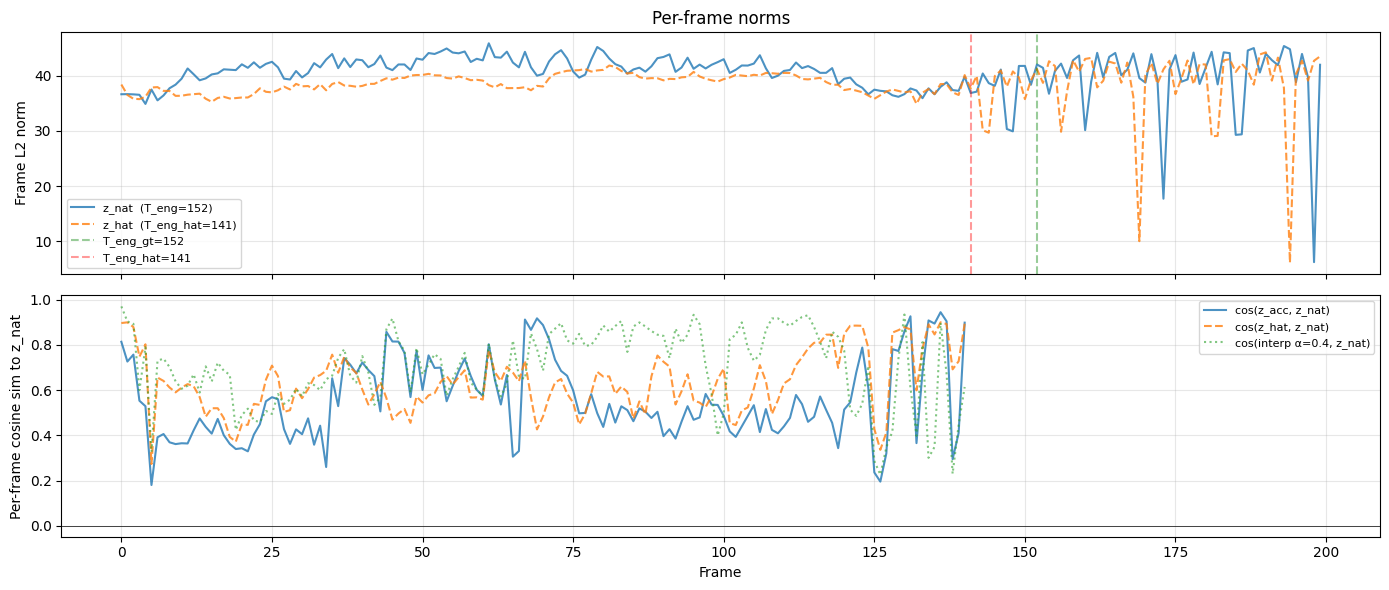

In [12]:
import matplotlib.pyplot as plt

SHOW = 200  # frames to plot

norm_acc = z_acc[:SHOW].norm(dim=-1).numpy()
norm_nat = z_nat[:SHOW].norm(dim=-1).numpy()
norm_hat = z_nat_hat_cpu[:SHOW].norm(dim=-1).numpy()
z_interp_04, _ = make_dtw_interp(0.4, path, z_acc, z_nat, T_l2, T_eng_gt)
norm_interp = z_interp_04[:SHOW].norm(dim=-1).numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax = axes[0]
# ax.plot(norm_acc,   label=f'z_acc  (T_l2={T_l2})',    alpha=0.8)
ax.plot(norm_nat,   label=f'z_nat  (T_eng={T_eng_gt})', alpha=0.8)
ax.plot(norm_hat,   label=f'z_hat  (T_eng_hat={T_eng_hat})', alpha=0.8, linestyle='--')
# ax.plot(norm_interp, label='interp α=0.4 (on-manifold)', alpha=0.6, linestyle=':')
# ax.axvline(T_l2,     color='blue',   linestyle='--', alpha=0.4, label=f'T_l2={T_l2}')
ax.axvline(T_eng_gt, color='green',  linestyle='--', alpha=0.4, label=f'T_eng_gt={T_eng_gt}')
ax.axvline(T_eng_hat,color='red',    linestyle='--', alpha=0.4, label=f'T_eng_hat={T_eng_hat}')
ax.set_ylabel('Frame L2 norm')
ax.set_title('Per-frame norms')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Per-frame cosine sim of z_hat to z_nat
ax2 = axes[1]
N = min(T_eng_gt, T_eng_hat, T_l2)
cos_hat_frame   = torch.nn.functional.cosine_similarity(z_nat_hat_cpu[:N], z_nat[:N], dim=-1).numpy()
cos_acc_frame   = torch.nn.functional.cosine_similarity(z_acc[:N],         z_nat[:N], dim=-1).numpy()
cos_interp_frame= torch.nn.functional.cosine_similarity(
    make_dtw_interp(0.4, path, z_acc, z_nat, T_l2, T_eng_gt)[0][:N], z_nat[:N], dim=-1).numpy()

ax2.plot(cos_acc_frame,    label='cos(z_acc, z_nat)',    alpha=0.8)
ax2.plot(cos_hat_frame,    label='cos(z_hat, z_nat)',    alpha=0.8, linestyle='--')
ax2.plot(cos_interp_frame, label='cos(interp α=0.4, z_nat)', alpha=0.6, linestyle=':')
ax2.axhline(0, color='k', linewidth=0.5)
ax2.set_ylabel('Per-frame cosine sim to z_nat')
ax2.set_xlabel('Frame')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('notebooks/frame_inspection.png', dpi=150)
plt.show()
# print('Saved: notebooks/frame_inspection.png')

## 9. Padding surgery — isolate speech vs tail as the culprit

In [11]:
print(f'Reference: "{PAIR["text"]}"\n')

def attach_acc_silence(speech_z, T_speech, T_l2, z_acc, L=1500):
    """z[:T_speech] from speech_z, then z_acc[T_l2:] silence — tile last frame if short."""
    z = speech_z.clone()
    n_needed = L - T_speech
    n_avail  = L - T_l2
    if n_avail >= n_needed:
        z[T_speech:] = z_acc[T_l2 : T_l2 + n_needed]
    else:
        # T_speech < T_l2: need more silence than available — tile last frame
        z[T_speech : T_speech + n_avail] = z_acc[T_l2:]
        z[T_speech + n_avail :]          = z_acc[-1:].expand(n_needed - n_avail, -1)
    return z

# A: z_hat speech + z_acc silence at T_eng_hat (key test — if this decodes, speech frames are fine)
z_hat_acc_sil = attach_acc_silence(z_nat_hat_cpu, T_eng_hat, T_l2, z_acc)
decode(z_hat_acc_sil, 'z_hat speech + z_acc silence @ T_eng_hat')

# B: z_acc speech + z_acc silence but shifted to T_eng_hat (sanity — should decode)
z_acc_shifted = attach_acc_silence(z_acc, T_eng_hat, T_l2, z_acc)
decode(z_acc_shifted, 'z_acc speech + z_acc silence @ T_eng_hat (sanity)')

# C: on-manifold DTW interp at matched cos_sim — confirms on-manifold decodes at this level
n = min(T_l2, T_eng_gt)
cos_hat = torch.nn.functional.cosine_similarity(
    z_nat_hat_cpu[:n], z_nat[:n], dim=-1).mean().item()
best_alpha, best_diff = 0.5, 1.0
for a in torch.linspace(0, 1, 101):
    z_tmp = a.item() * z_acc[:n] + (1 - a.item()) * z_nat[:n]
    c = torch.nn.functional.cosine_similarity(z_tmp, z_nat[:n], dim=-1).mean().item()
    if abs(c - cos_hat) < best_diff:
        best_diff, best_alpha = abs(c - cos_hat), a.item()
z_matched, N_matched = make_dtw_interp(best_alpha, path, z_acc, z_nat, T_l2, T_eng_gt)
cos_matched = torch.nn.functional.cosine_similarity(z_matched[:n], z_nat[:n], dim=-1).mean().item()
print(f'\nMatched interp: alpha={best_alpha:.2f} → cos={cos_matched:.4f}  (z_hat cos={cos_hat:.4f})')
decode(z_matched, f'on-manifold interp α={best_alpha:.2f} (same cos_sim as z_hat)')


Reference: "Sheldon glanced at the thermometer"

[z_hat speech + z_acc silence @ T_eng_hat] " You"
[z_acc speech + z_acc silence @ T_eng_hat (sanity)] " Sheldon glanced at the thermometer."

Matched interp: alpha=0.90 → cos=0.5877  (z_hat cos=0.6248)
[on-manifold interp α=0.90 (same cos_sim as z_hat)] " Sheldon glanced at the thermometer."


' Sheldon glanced at the thermometer.'